In [3]:
import torch
from torchvision.transforms import v2
from torchvision.io import decode_image, read_image
import matplotlib.pyplot as plt
from helpers import plot        # helper funktion von PyTorch Doku

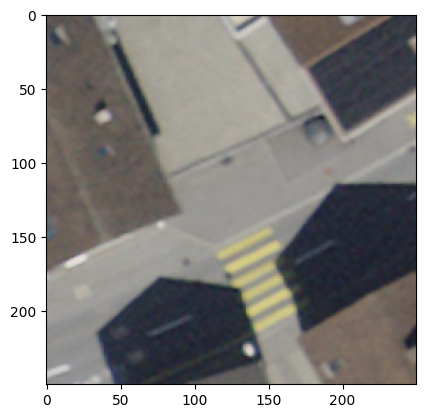

In [4]:
img_path = '../swissimage_annotator/static/data/st gallen/y/2753025_1188375.png'

img = read_image(img_path)
img_numpy = img.numpy().transpose(1, 2, 0)
plt.imshow(img_numpy)
plt.show()

# Basic Image Data Augmentation

## Composition: Randomcrop, Randomflip, Normalisierung

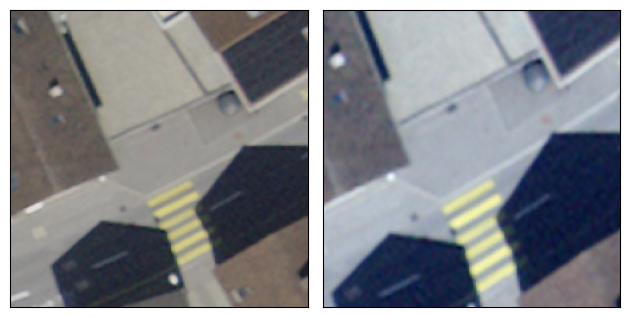

In [21]:
transforms = v2.Compose([
    v2.RandomResizedCrop(size=(224, 224), antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
out = transforms(img)
plot([img, out])

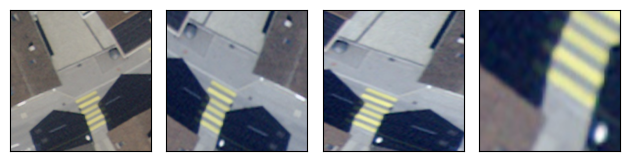

In [22]:
plot_list = [img]
for i in range(3):
    out = transforms(img)
    plot_list.append(out)

plot(plot_list)

## Composition: Rotation, Crop

Es ist zu sehen, dass es manchmal dazu kommen kann, dass die wichtigsten Merkmale nicht mehr auf dem Bild zu sehen werden (Zebrastreifen).

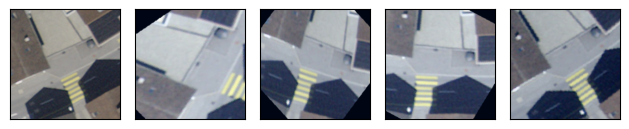

In [38]:
transforms = v2.Compose([
    v2.RandomRotation(45),
    v2.RandomResizedCrop(size=(224, 224), antialias=True),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
plot_list = [img]
for i in range(4):
    out = transforms(img)
    plot_list.append(out)

plot(plot_list)

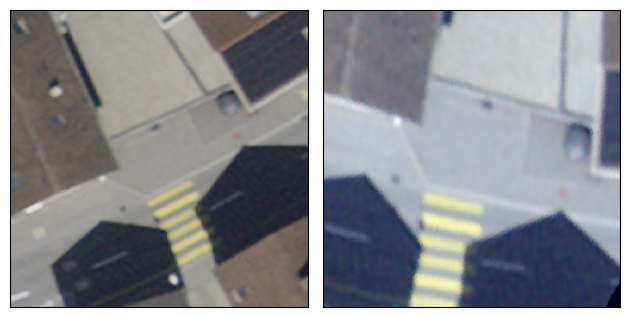

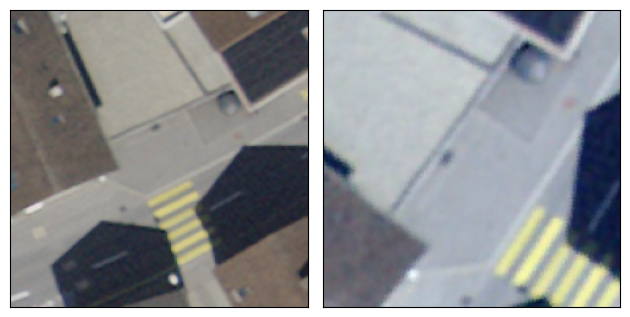

In [6]:
transforms = v2.Compose([
    v2.RandomRotation(45),
    v2.RandomResizedCrop(size=(224, 224), antialias=True),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
for i in range(2):
    out = transforms(img)
    plot([img, out])



## Composition: Blur

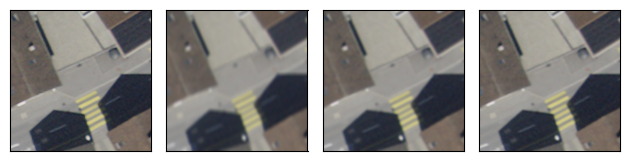

In [ ]:
transforms = v2.Compose([
    v2.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)),
    v2.ToDtype(torch.float32, scale=True),
    #v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
plot_list = [img]
for i in range(3):
    out = transforms(img)
    plot_list.append(out)

plot(plot_list)

## Random Perspective

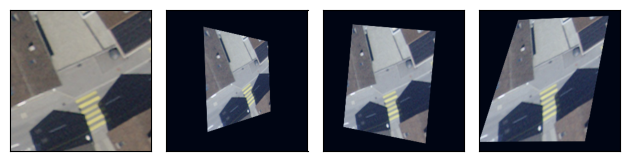

In [36]:
transforms = v2.Compose([
    v2.RandomPerspective(distortion_scale=0.6, p=1.0),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
plot_list = [img]
for i in range(3):
    out = transforms(img)
    plot_list.append(out)

plot(plot_list)

# Composition: Flip, Rotation, Crop, Perspective, Blur

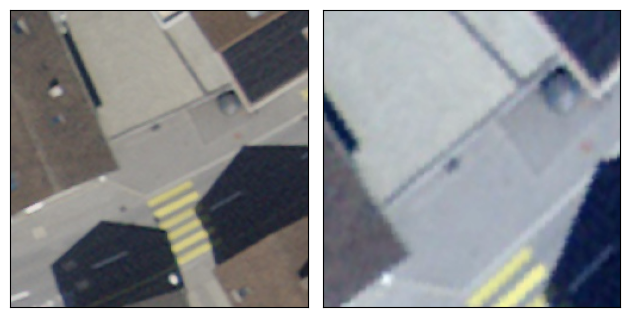

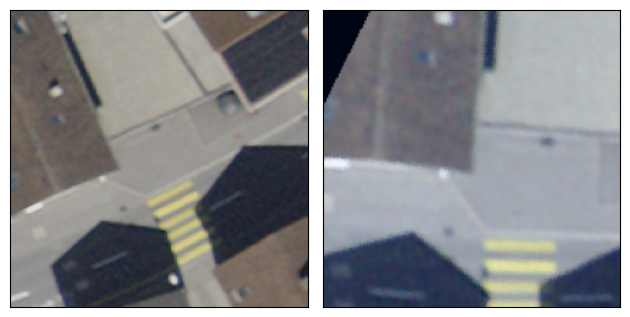

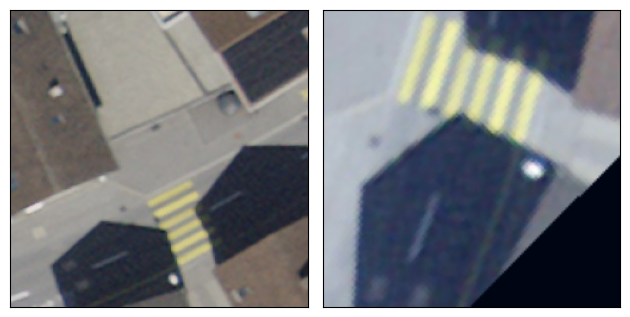

In [7]:
v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomResizedCrop(size=(224, 224), antialias=True),
    v2.RandomRotation(6),
    v2.RandomPerspective(distortion_scale=0.6, p=1.0),
    v2.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
for i in range(3):
    out = transforms(img)
    plot([img, out])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.4656866].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.6813947].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.4656866].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0299785].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.1855743].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.5007006].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.41

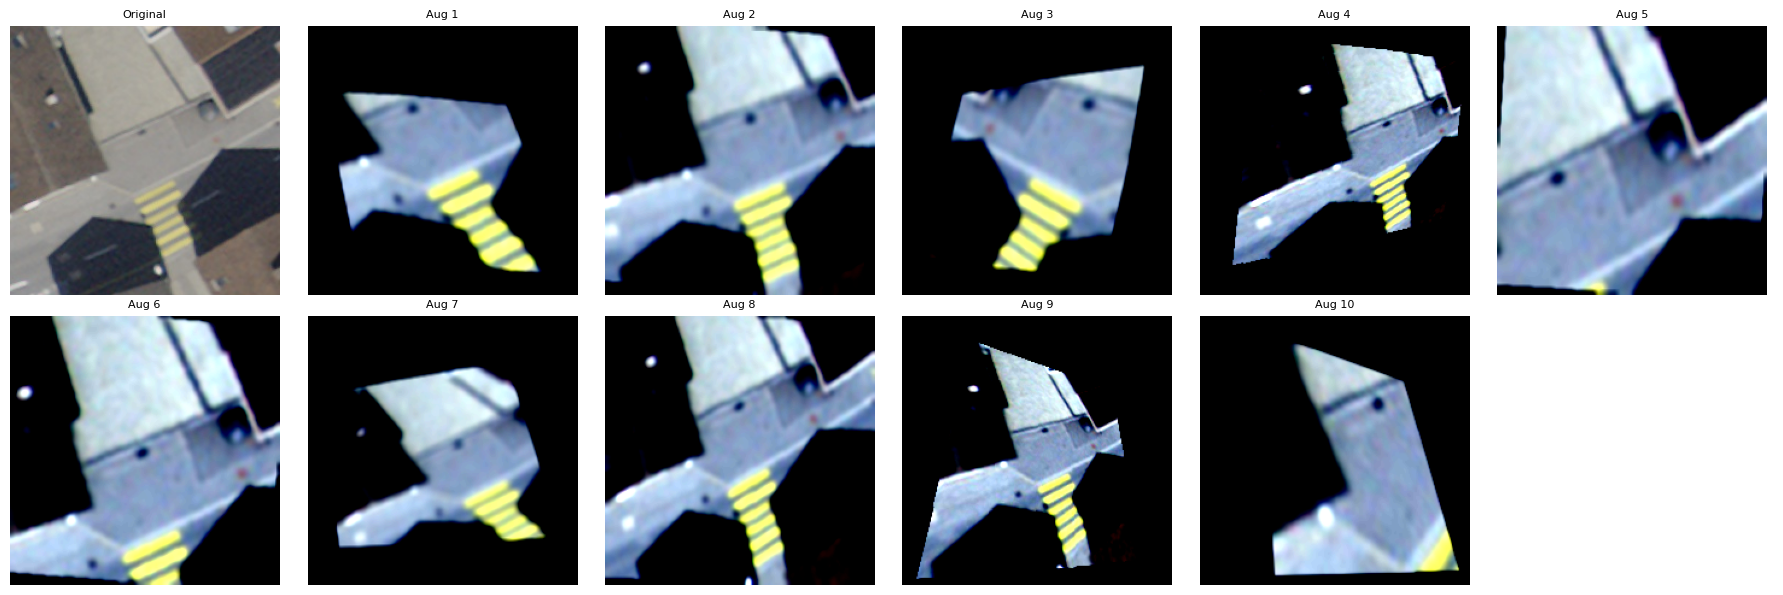

In [ ]:
import math
plots = [img]
transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.25),
    #v2.RandomResizedCrop(size=(224, 224), antialias=True),
    v2.RandomRotation(6),
    v2.RandomPerspective(distortion_scale=0.6, p=0.5),
    v2.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
for i in range(10):
    out = transforms(img)
    plots.append(out)

n_cols = 6
n_rows = math.ceil(len(plots) / n_cols)  # 6 rows for 33 images

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
axes = axes.flatten()

for i, (ax, tensor) in enumerate(zip(axes, plots)):
    img_np = tensor.numpy()

    # Undo normalization for augmented images so they display correctly
    if img_np.dtype == float or img_np.max() <= 1.0:
        mean = [0.485, 0.456, 0.406]
        std  = [0.229, 0.224, 0.225]
        img_np = img_np * std[:, None, None] + mean[:, None, None]  # un-normalize
        img_np = img_np.clip(0, 1)

    ax.imshow(img_np.transpose(1, 2, 0))
    ax.set_title("Original" if i == 0 else f"Aug {i}", fontsize=8)
    ax.axis("off")

# Hide any unused subplots
for ax in axes[len(plots):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("augmented_grid.png", dpi=150, bbox_inches="tight")
plt.show()
